In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler

pd.set_option("display.max_columns", None)

In [2]:
train_path = "../data/raw/UNSW_NB15_training-set.csv"
test_path = "../data/raw/UNSW_NB15_testing-set.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

Training data shape: (175341, 45)
Testing data shape: (82332, 45)


In [3]:
# Display all column names
print("Columns in dataset:")
print(train_df.columns.tolist())

# Check data types
print("\nData types:")
print(train_df.dtypes)

# Check missing values
print("\nMissing values:")
print(train_df.isnull().sum())

# Check target distribution
print("\nTarget distribution:")
print(train_df["label"].value_counts())

Columns in dataset:
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

Data types:
id                     int64
dur                  float64
proto                 object
service               object
state                 object
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss          

In [4]:
# Basic dataset inspection

print("Training dataset information:")
train_df.info()

print("\n" + "="*60)

print("Testing dataset information:")
test_df.info()

print("\n" + "="*60)

print("Training missing values:")
print(train_df.isnull().sum())

print("\n" + "="*60)

print("Attack categories:")
print(train_df["attack_cat"].value_counts())

print("\n" + "="*60)

print("Labels:")
print(train_df["label"].value_counts())

Training dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              17

In [5]:
# Check categorical (object) columns

categorical_cols = train_df.select_dtypes(include="object").columns

print("Categorical columns:")
print(list(categorical_cols))

print("\nNumber of categorical columns:", len(categorical_cols))

for col in categorical_cols:
    print(f"\n{col}:")
    print(train_df[col].value_counts().head(10))

Categorical columns:
['proto', 'service', 'state', 'attack_cat']

Number of categorical columns: 4

proto:
proto
tcp       79946
udp       63283
unas      12084
arp        2859
ospf       2595
sctp       1150
any         300
gre         225
sun-nd      201
ipv6        201
Name: count, dtype: int64

service:
service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp           94
snmp           80
Name: count, dtype: int64

state:
state
INT    82275
FIN    77825
CON    13152
REQ     1991
RST       83
ECO       12
PAR        1
URN        1
no         1
Name: count, dtype: int64

attack_cat:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


In [6]:
# Check missing values and duplicate rows

print("Missing values:")
print(train_df.isnull().sum())

print("\nDuplicate rows:")
print("Training duplicates:", train_df.duplicated().sum())
print("Testing duplicates:", test_df.duplicated().sum())

print("\nData types:")
print(train_df.dtypes)

Missing values:
id                   0
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_sm_ips_ports   

In [7]:
# Identify categorical and numerical columns

categorical_cols = train_df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = train_df.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumber of categorical columns:", len(categorical_cols))

print("\nNumerical columns:")
print(numerical_cols)

print("\nUnique values in categorical columns:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(train_df[col].value_counts().head(10))

Categorical columns:
['proto', 'service', 'state', 'attack_cat']

Number of categorical columns: 4

Numerical columns:
['id', 'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'label']

Unique values in categorical columns:

proto:
proto
tcp       79946
udp       63283
unas      12084
arp        2859
ospf       2595
sctp       1150
any         300
gre         225
sun-nd      201
ipv6        201
Name: count, dtype: int64

service:
service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp  

In [8]:
# Separate features (X) and target (y)

# Drop ID and attack category from input features
drop_cols = ["id", "attack_cat", "label"]

X_train = train_df.drop(columns=drop_cols)
X_test = test_df.drop(columns=drop_cols)

y_train = train_df["label"]
y_test = test_df["label"]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (175341, 42)
X_test shape: (82332, 42)
y_train shape: (175341,)
y_test shape: (82332,)


In [9]:
# One-hot encode categorical features

categorical_cols = ["proto", "service", "state"]

X_train = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    drop_first=False
)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=False
)

# Make sure training and testing have exactly the same columns
X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

# Convert boolean columns to integers
X_train = X_train.astype(int)
X_test = X_test.astype(int)

print("Encoded X_train shape:", X_train.shape)
print("Encoded X_test shape:", X_test.shape)

print("\nTarget distribution:")
print(y_train.value_counts())

Encoded X_train shape: (175341, 194)
Encoded X_test shape: (82332, 194)

Target distribution:
label
1    119341
0     56000
Name: count, dtype: int64


In [11]:
# Reset X_train and X_test from original datasets

drop_cols = ["id", "attack_cat", "label"]

X_train = train_df.drop(columns=drop_cols).copy()
X_test = test_df.drop(columns=drop_cols).copy()

y_train = train_df["label"].copy()
y_test = test_df["label"].copy()

# Categorical columns
categorical_cols = ["proto", "service", "state"]

# One-hot encoding
X_train = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    drop_first=False
)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=False
)

# Make train and test columns identical
X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

# Convert boolean columns to integers
X_train = X_train.astype(int)
X_test = X_test.astype(int)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (175341, 194)
X_test shape: (82332, 194)

y_train shape: (175341,)
y_test shape: (82332,)


In [12]:
# Clean numerical data

# Replace infinite values with NaN
train_df = train_df.replace([np.inf, -np.inf], np.nan)
test_df = test_df.replace([np.inf, -np.inf], np.nan)

# Check missing values after replacing infinities
print("Missing values in training data:")
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])

print("\nMissing values in testing data:")
print(test_df.isnull().sum()[test_df.isnull().sum() > 0])

Missing values in training data:
Series([], dtype: int64)

Missing values in testing data:
Series([], dtype: int64)


In [13]:
# Remove duplicate rows

print("Duplicates before cleaning:")
print("Training:", train_df.duplicated().sum())
print("Testing:", test_df.duplicated().sum())

train_df = train_df.drop_duplicates()
test_df = test_df.drop_duplicates()

print("\nDuplicates after cleaning:")
print("Training:", train_df.duplicated().sum())
print("Testing:", test_df.duplicated().sum())

print("\nShapes after removing duplicates:")
print("Training:", train_df.shape)
print("Testing:", test_df.shape)

Duplicates before cleaning:
Training: 0
Testing: 0

Duplicates after cleaning:
Training: 0
Testing: 0

Shapes after removing duplicates:
Training: (175341, 45)
Testing: (82332, 45)


In [14]:
# Check for missing values

print("Missing values in training data:")
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])

print("\nMissing values in testing data:")
print(test_df.isnull().sum()[test_df.isnull().sum() > 0])

Missing values in training data:
Series([], dtype: int64)

Missing values in testing data:
Series([], dtype: int64)


In [15]:
# Check binary label distribution after cleaning

print("Training label distribution:")
print(train_df["label"].value_counts())

print("\nTesting label distribution:")
print(test_df["label"].value_counts())

# Percentage distribution
print("\nTraining label percentage:")
print(train_df["label"].value_counts(normalize=True) * 100)

print("\nTesting label percentage:")
print(test_df["label"].value_counts(normalize=True) * 100)

Training label distribution:
label
1    119341
0     56000
Name: count, dtype: int64

Testing label distribution:
label
1    45332
0    37000
Name: count, dtype: int64

Training label percentage:
label
1    68.062233
0    31.937767
Name: proportion, dtype: float64

Testing label percentage:
label
1    55.060001
0    44.939999
Name: proportion, dtype: float64


In [16]:
# Check attack categories in UNSW-NB15

print("Attack categories:")
print(train_df["attack_cat"].value_counts())

print("\nNumber of attack categories:")
print(train_df["attack_cat"].nunique())

Attack categories:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

Number of attack categories:
10


In [17]:
# Create binary target for UNSW-NB15

train_df["Label_binary"] = train_df["label"].map({
    0: "BENIGN",
    1: "ATTACK"
})

test_df["Label_binary"] = test_df["label"].map({
    0: "BENIGN",
    1: "ATTACK"
})

print("Training binary label distribution:")
print(train_df["Label_binary"].value_counts())

print("\nTesting binary label distribution:")
print(test_df["Label_binary"].value_counts())

Training binary label distribution:
Label_binary
ATTACK    119341
BENIGN     56000
Name: count, dtype: int64

Testing binary label distribution:
Label_binary
ATTACK    45332
BENIGN    37000
Name: count, dtype: int64


In [18]:
# Clean numerical features

# Get numerical columns
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()

# Remove target columns from numerical features
numeric_cols = [
    col for col in numeric_cols
    if col not in ["label"]
]

# Replace infinite values with NaN
train_df[numeric_cols] = train_df[numeric_cols].replace(
    [np.inf, -np.inf], np.nan
)

test_df[numeric_cols] = test_df[numeric_cols].replace(
    [np.inf, -np.inf], np.nan
)

# Fill missing numerical values with training median
for col in numeric_cols:
    median_value = train_df[col].median()
    
    train_df[col] = train_df[col].fillna(median_value)
    test_df[col] = test_df[col].fillna(median_value)

print("Numerical columns cleaned:", len(numeric_cols))

print("\nRemaining missing values in training:",
      train_df[numeric_cols].isnull().sum().sum())

print("Remaining missing values in testing:",
      test_df[numeric_cols].isnull().sum().sum())

Numerical columns cleaned: 40

Remaining missing values in training: 0
Remaining missing values in testing: 0


In [19]:
# Verify cleaned dataset

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

print("\nTotal missing values:")
print("Training:", train_df.isnull().sum().sum())
print("Testing:", test_df.isnull().sum().sum())

print("\nInfinite values:")
print("Training:", np.isinf(train_df.select_dtypes(include=np.number)).sum().sum())
print("Testing:", np.isinf(test_df.select_dtypes(include=np.number)).sum().sum())

Training shape: (175341, 46)
Testing shape: (82332, 46)

Total missing values:
Training: 0
Testing: 0

Infinite values:
Training: 0
Testing: 0


In [20]:
# Separate features (X) and target (y)

X_train = train_df.drop(columns=["label"])
y_train = train_df["label"]

X_test = test_df.drop(columns=["label"])
y_test = test_df["label"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (175341, 45)
y_train shape: (175341,)
X_test shape: (82332, 45)
y_test shape: (82332,)


In [21]:
# Encode categorical columns

categorical_cols = ["proto", "service", "state"]

X_train = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    drop_first=False
)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=False
)

# Make sure train and test have exactly the same columns
X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

print("X_train shape after encoding:", X_train.shape)
print("X_test shape after encoding:", X_test.shape)
print("All features are numeric:", X_train.dtypes.eq("object").sum() == 0)

X_train shape after encoding: (175341, 197)
X_test shape after encoding: (82332, 197)
All features are numeric: False


In [24]:
# Encode any remaining categorical columns

categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Categorical columns remaining:", categorical_cols)

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=False)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=False)

# Make train and test columns identical
X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

# Convert boolean columns to integers
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)

Categorical columns remaining: ['Label_binary']
Scaled X_train shape: (175341, 197)
Scaled X_test shape: (82332, 197)


In [25]:
# Check target class distribution

print("Training class distribution:")
print(y_train.value_counts())

print("\nTraining class percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
label
1    119341
0     56000
Name: count, dtype: int64

Training class percentages:
label
1    68.06
0    31.94
Name: proportion, dtype: float64

Testing class distribution:
label
1    45332
0    37000
Name: count, dtype: int64


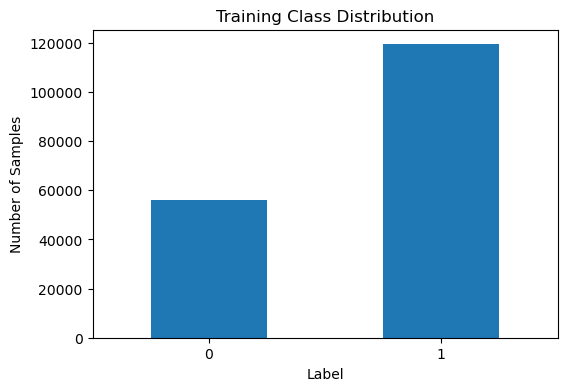

In [26]:
# Visualize class distribution

plt.figure(figsize=(6, 4))

y_train.value_counts().sort_index().plot(kind="bar")

plt.title("Training Class Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)

plt.show()

In [27]:
# Statistical summary of numerical features

print("Training data statistics:")
print(pd.DataFrame(X_train_scaled).describe())

Training data statistics:
                0             1             2             3             4    \
count  1.753410e+05  1.753410e+05  1.753410e+05  1.753410e+05  1.753410e+05   
mean   2.593503e-17 -3.241878e-18 -1.426426e-17  5.187005e-18 -1.053610e-18   
std    1.000003e+00  1.000003e+00  1.000003e+00  1.000003e+00  1.000003e+00   
min   -1.732041e+00 -2.097747e-01 -1.409822e-01 -1.720474e-01 -5.044967e-02   
25%   -8.660205e-01 -2.097735e-01 -1.336769e-01 -1.720474e-01 -4.995758e-02   
50%    0.000000e+00 -2.095306e-01 -1.336769e-01 -1.539081e-01 -4.814944e-02   
75%    8.660205e-01 -1.066813e-01 -6.062410e-02 -8.135096e-02 -4.249614e-02   
max    1.732041e+00  9.049154e+00  7.009933e+01  9.935819e+01  7.413600e+01   

                5             6             7             8             9    \
count  1.753410e+05  1.753410e+05  1.753410e+05  1.753410e+05  1.753410e+05   
mean   1.410217e-17 -3.241878e-17 -1.607972e-16 -1.141141e-16  1.167076e-17   
std    1.000003e+00  1.00

In [28]:
# Check correlation of numerical features with target

correlation = train_df.select_dtypes(include=np.number).corr()["label"].sort_values(
    ascending=False
)

print("Feature correlation with target:")
print(correlation)

Feature correlation with target:
label                1.000000
id                   0.727173
sttl                 0.692741
ct_state_ttl         0.577704
ct_dst_sport_ltm     0.357213
rate                 0.337979
ct_src_dport_ltm     0.305579
ct_dst_src_ltm       0.303855
ct_src_ltm           0.238225
ct_dst_ltm           0.229887
ct_srv_src           0.229044
ct_srv_dst           0.228046
sload                0.182870
ackdat               0.097364
dttl                 0.095049
tcprtt               0.081584
synack               0.058299
dur                  0.036175
sbytes               0.018576
ct_flw_http_mthd     0.015800
trans_depth          0.010801
sloss               -0.000640
sjit                -0.007069
smean               -0.010798
is_ftp_login        -0.011055
ct_ftp_cmd          -0.011055
response_body_len   -0.021361
dinpkt              -0.022887
spkts               -0.052178
djit                -0.060870
dbytes              -0.076871
dloss               -0.094685
dpkts  

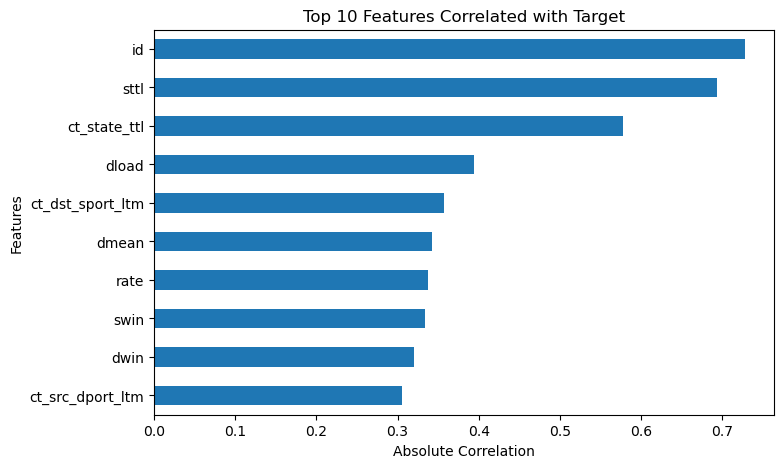

In [29]:
# Plot top features correlated with the target

top_corr = correlation.drop("label").abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
top_corr.sort_values().plot(kind="barh")

plt.title("Top 10 Features Correlated with Target")
plt.xlabel("Absolute Correlation")
plt.ylabel("Features")

plt.show()

In [30]:
# Select top features based on correlation with the target

# Calculate absolute correlation with target
correlation_with_target = X_train.corrwith(y_train).abs()

# Sort features by correlation
correlation_with_target = correlation_with_target.sort_values(ascending=False)

# Display top 20 features
top_features = correlation_with_target.head(20)

print("Top 20 features correlated with target:")
print(top_features)

Top 20 features correlated with target:
Label_binary_BENIGN    1.000000
Label_binary_ATTACK    1.000000
id                     0.727173
sttl                   0.692741
ct_state_ttl           0.577704
state_INT              0.503995
dload                  0.393739
state_CON              0.366805
ct_dst_sport_ltm       0.357213
dmean                  0.341806
rate                   0.337979
proto_tcp              0.333726
swin                   0.333633
dwin                   0.319626
ct_src_dport_ltm       0.305579
ct_dst_src_ltm         0.303855
state_FIN              0.303311
stcpb                  0.255006
dtcpb                  0.250340
ct_src_ltm             0.238225
dtype: float64


In [31]:
# Remove target leakage features
# These columns are directly derived from the target label

leakage_cols = [
    "Label_binary_BENIGN",
    "Label_binary_ATTACK"
]

X_train_clean = X_train.drop(columns=leakage_cols, errors="ignore")
X_test_clean = X_test.drop(columns=leakage_cols, errors="ignore")

print("Training shape after removing leakage:", X_train_clean.shape)
print("Testing shape after removing leakage:", X_test_clean.shape)

print("\nRemaining columns:")
print(X_train_clean.columns.tolist())

Training shape after removing leakage: (175341, 195)
Testing shape after removing leakage: (82332, 195)

Remaining columns:
['id', 'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'proto_3pc', 'proto_a/n', 'proto_aes-sp3-d', 'proto_any', 'proto_argus', 'proto_aris', 'proto_arp', 'proto_ax.25', 'proto_bbn-rcc', 'proto_bna', 'proto_br-sat-mon', 'proto_cbt', 'proto_cftp', 'proto_chaos', 'proto_compaq-peer', 'proto_cphb', 'proto_cpnx', 'proto_crtp', 'proto_crudp', 'proto_dcn', 'proto_ddp', 'proto_ddx', 'proto_dgp', 'proto_egp', 'proto_eigrp', 'proto_emcon', 'proto_encap', 'proto_etherip',

In [32]:
# Feature Selection
# Remove target-derived and identifier features

selected_features = [
    'sttl',
    'ct_state_ttl',
    'dload',
    'ct_dst_sport_ltm',
    'dmean',
    'rate',
    'swin',
    'dwin',
    'ct_src_dport_ltm',
    'ct_dst_src_ltm',
    'ct_src_ltm',
    'ct_dst_ltm',
    'ct_srv_src',
    'ct_srv_dst',
    'sload',
    'ackdat',
    'dttl',
    'tcprtt',
    'synack',
    'dur'
]

# Keep only features that actually exist
selected_features = [f for f in selected_features if f in X_train.columns]

X_train_selected = X_train[selected_features].copy()
X_test_selected = X_test[selected_features].copy()

print("Selected features:", len(selected_features))
print("\nFeatures:")
print(selected_features)

print("\nTraining shape:", X_train_selected.shape)
print("Testing shape:", X_test_selected.shape)

Selected features: 20

Features:
['sttl', 'ct_state_ttl', 'dload', 'ct_dst_sport_ltm', 'dmean', 'rate', 'swin', 'dwin', 'ct_src_dport_ltm', 'ct_dst_src_ltm', 'ct_src_ltm', 'ct_dst_ltm', 'ct_srv_src', 'ct_srv_dst', 'sload', 'ackdat', 'dttl', 'tcprtt', 'synack', 'dur']

Training shape: (175341, 20)
Testing shape: (82332, 20)


In [33]:
# Prepare final training and testing data

X_train_final = X_train_selected.copy()
X_test_final = X_test_selected.copy()

y_train_final = y_train.copy()
y_test_final = y_test.copy()

print("Final training data shape:", X_train_final.shape)
print("Final testing data shape:", X_test_final.shape)
print("Training target shape:", y_train_final.shape)
print("Testing target shape:", y_test_final.shape)

Final training data shape: (175341, 20)
Final testing data shape: (82332, 20)
Training target shape: (175341,)
Testing target shape: (82332,)


In [34]:
# Scale selected features for model training

scaler_final = StandardScaler()

X_train_final_scaled = scaler_final.fit_transform(X_train_final)
X_test_final_scaled = scaler_final.transform(X_test_final)

print("Final scaled training shape:", X_train_final_scaled.shape)
print("Final scaled testing shape:", X_test_final_scaled.shape)

Final scaled training shape: (175341, 20)
Final scaled testing shape: (82332, 20)
